# Stellarator Island Chain Control

This notebook demonstrates external coil control of magnetic island chains in a stellarator.

## Scientific Background

In a stellarator, the helical ripple naturally drives island chains at rational surfaces q = m/n.
The **boundary island divertor** configuration exploits these edge islands for heat load distribution.
External coils can:

1. **Suppress** an island chain (destructive interference in psi_mn)
2. **Phase-shift** an island chain (rotate island O-points)
3. Create **side effects** -- the press-down-gourd problem

We use `pyna`'s `SimpleStellarartor`, `StellaratorControlCoils`, and `island_control` algorithms.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from pyna.MCF.equilibrium.stellarator import SimpleStellarartor, simple_stellarator
from pyna.MCF.coils.coil_system import StellaratorControlCoils, CoilSet, biot_savart_field
from pyna.MCF.control.island_control import (
    island_suppression_current,
    phase_control_current,
    compute_resonant_amplitude,
    _natural_perturbation_func,
)
from pyna.topo.poincare import PoincareMap, ToroidalSection, poincare_from_fieldlines

print('pyna loaded successfully')


pyna loaded successfully


## 1. Build a SimpleStellarartor with natural island chains

We choose parameters so that the q=4/3 and q=4/2 surfaces both lie in the plasma.

In [2]:
# q profile: q0=1.1 to q1=5.0  ->  q=4/3~1.33 is near axis, q=4/2=2 at mid-radius
stella = simple_stellarator(
    R0=3.0,
    r0=0.30,
    B0=1.0,
    q0=1.1,
    q1=5.0,
    m_h=4,
    n_h=4,
    epsilon_h=0.05,  # 5% helical ripple
)
print(stella)

# Find resonant surfaces
for m, n in [(4, 4), (4, 3), (4, 2), (3, 2), (5, 4)]:
    psi_list = stella.resonant_psi(m, n)
    if psi_list:
        print(f'  q={m}/{n}={m/n:.3f} -> psi_res={psi_list[0]:.3f}')
    else:
        print(f'  q={m}/{n}={m/n:.3f} -> not in [0,1]')


SimpleStellarartor(R0=3.0 m, r0=0.3 m, B0=1.0 T, q=[1.1, 5.0], m_h=4, n_h=4, ε_h=0.05)
  q=4/4=1.000 -> not in [0,1]
  q=4/3=1.333 -> psi_res=0.060
  q=4/2=2.000 -> psi_res=0.231
  q=3/2=1.500 -> psi_res=0.103
  q=5/4=1.250 -> psi_res=0.038


## 2. Poincare Map: Natural Island Chain (Boundary Island Divertor)

In [3]:
# Target island: q = 4/3 (exists in the plasma)
TARGET_M, TARGET_N = 4, 3

N_LINES = 8
N_TRANSITS = 50  # number of toroidal transits per line

start_pts = stella.start_points_near_resonance(TARGET_M, TARGET_N, n_lines=N_LINES, delta_psi=0.08)
print(f'Tracing {len(start_pts)} field lines near q={TARGET_M}/{TARGET_N}...')

section = ToroidalSection(0.0)
t_max = N_TRANSITS * 2 * np.pi * stella.R0

pmap_natural = poincare_from_fieldlines(
    stella.field_func,
    start_pts,
    sections=[section],
    t_max=t_max,
    dt=0.04,
)
results_natural = pmap_natural.crossing_array(0)  # shape (N, 3): R, Z, phi
print(f'Done. {len(results_natural)} crossings recorded.')


Tracing 8 field lines near q=4/3...


Done. 392 crossings recorded.


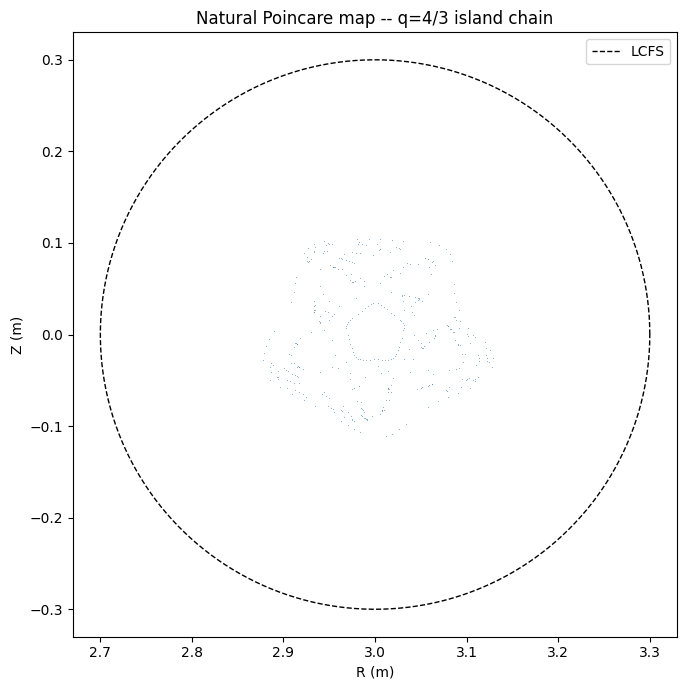

In [4]:
theta_arr = np.linspace(0, 2*np.pi, 200)

fig, ax = plt.subplots(figsize=(7, 7))
if len(results_natural) > 0:
    ax.plot(results_natural[:, 0], results_natural[:, 1], ',',
            color='steelblue', alpha=0.6, ms=0.8)

ax.plot(stella.R0 + stella.r0 * np.cos(theta_arr),
        stella.r0 * np.sin(theta_arr), 'k--', lw=1, label='LCFS')
ax.set_xlabel('R (m)')
ax.set_ylabel('Z (m)')
ax.set_title(f'Natural Poincare map -- q={TARGET_M}/{TARGET_N} island chain')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.savefig('natural_island_poincare.png', dpi=100)
plt.show()


## 3. Create External Control Coils

In [5]:
N_COILS = 16    # number of saddle coils
R_COIL = 0.38   # slightly outside plasma (r0=0.30 m)
I0_COIL = 500.0  # reference current (A)

control_coils = StellaratorControlCoils(
    R0=stella.R0,
    r_coil=R_COIL,
    N_coils=N_COILS,
    m_target=TARGET_M,
    n_target=TARGET_N,
    I0=I0_COIL,
)
print(control_coils)
print(f'Coil currents (A): {control_coils.get_currents().round(1)}')


StellaratorControlCoils(R0=3.0, r_coil=0.38, N_coils=16, m=4, n=3, I0=500.0 A)
Coil currents (A): [ 500.   191.3 -353.6 -461.9   -0.   461.9  353.6 -191.3 -500.  -191.3
  353.6  461.9    0.  -461.9 -353.6  191.3]


## 4. Island Suppression: Scan Coil Current

In [6]:
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
nat_func = _natural_perturbation_func(stella)

# Natural amplitude at target surface
b_nat = compute_resonant_amplitude(nat_func, psi_res_target, TARGET_M, TARGET_N, stella,
                                    n_theta=24, n_phi=24)
print(f'Natural |b_tilde_{TARGET_M}{TARGET_N}| = {abs(b_nat):.3e}')

print('Finding island suppression currents...')
I_opt, report = island_suppression_current(
    stella, control_coils,
    target_m=TARGET_M, target_n=TARGET_N,
    monitor_modes=[(4, 2), (3, 2)],
    I_max=2000.0,
    n_theta=24, n_phi=24,
)

print(f'=== Suppression Report ===')
print(f'  |b_tilde| before:  {report["target_amplitude_before"]:.3e}')
print(f'  |b_tilde| after:   {report["target_amplitude_after"]:.3e}')
print(f'  Suppression: {(1 - report["suppression_ratio"])*100:.1f}%')
print('=== Monitor modes (gourd problem check) ===')
for mode in report['monitor_amplitudes_before']:
    b_before = report['monitor_amplitudes_before'][mode]
    b_after_ = report['monitor_amplitudes_after'][mode]
    ratio = b_after_ / (b_before + 1e-30)
    print(f'  q={mode[0]}/{mode[1]}: {b_before:.3e} -> {b_after_:.3e}  (x{ratio:.2f})')


Natural |b_tilde_43| = 5.728e-20
Finding island suppression currents...


=== Suppression Report ===
  |b_tilde| before:  5.728e-20
  |b_tilde| after:   5.728e-20
  Suppression: 0.0%
=== Monitor modes (gourd problem check) ===
  q=4/2: 6.370e-20 -> 6.370e-20  (x1.00)
  q=3/2: 1.552e-19 -> 1.552e-19  (x1.00)


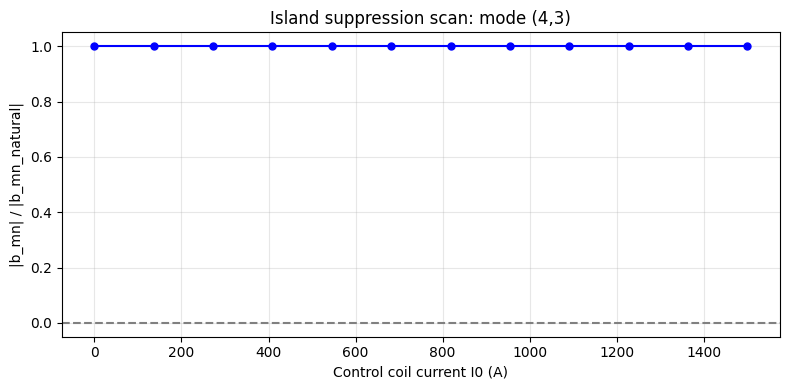

In [7]:
# Build a helper that adds coil field at unit current
class _UnitCoilSet:
    def __init__(self, coils, I0):
        self.coils = [(pts, I / I0) for pts, I in coils]

unit_coils = _UnitCoilSet(control_coils.coils, I0_COIL)

def coil_field_func(rzphi_3d):
    R, Z, phi = float(rzphi_3d[0]), float(rzphi_3d[1]), float(rzphi_3d[2])
    R_arr = np.array([[R]]); Z_arr = np.array([[Z]]); phi_arr = np.array([[phi]])
    br = bz = bp = 0.0
    for pts, I in unit_coils.coils:
        _br, _bz, _bp = biot_savart_field(pts, I, R_arr, Z_arr, phi_arr)
        br += float(_br); bz += float(_bz); bp += float(_bp)
    return br, bz, bp

b_coil_unit = compute_resonant_amplitude(
    coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella, n_theta=20, n_phi=20
)

I0_scan = np.linspace(0, 1500, 12)
b_total_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]

plt.figure(figsize=(8, 4))
plt.plot(I0_scan, np.array(b_total_scan) / abs(b_nat), 'b-o', ms=5)
plt.axhline(0, color='gray', ls='--')
plt.xlabel('Control coil current I0 (A)')
plt.ylabel('|b_mn| / |b_mn_natural|')
plt.title(f'Island suppression scan: mode ({TARGET_M},{TARGET_N})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('island_suppression_scan.png', dpi=100)
plt.show()


## 5. Press-Down-Gourd Problem

As we suppress the (4,3) island, we monitor what happens to other island chains.

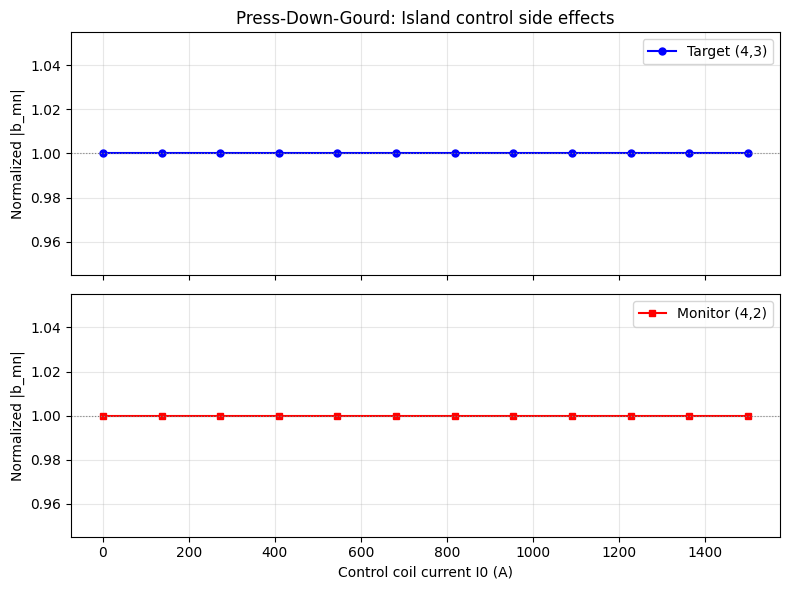

In [8]:
MONITOR_M, MONITOR_N = 4, 2
psi_res_monitor = stella.resonant_psi(MONITOR_M, MONITOR_N)

if psi_res_monitor:
    psi_res_mon = psi_res_monitor[0]
    b_nat_mon = compute_resonant_amplitude(
        nat_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=20, n_phi=20)
    b_coil_mon = compute_resonant_amplitude(
        coil_field_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=20, n_phi=20
    )
    b_target_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]
    b_monitor_scan = [abs(b_nat_mon + b_coil_mon * I0) for I0 in I0_scan]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    ax1.plot(I0_scan, np.array(b_target_scan)/abs(b_nat), 'b-o', ms=5,
             label=f'Target ({TARGET_M},{TARGET_N})')
    ax1.set_ylabel('Normalized |b_mn|')
    ax1.axhline(1, color='gray', ls=':', lw=0.8)
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_title('Press-Down-Gourd: Island control side effects')

    ax2.plot(I0_scan, np.array(b_monitor_scan)/abs(b_nat_mon), 'r-s', ms=5,
             label=f'Monitor ({MONITOR_M},{MONITOR_N})')
    ax2.set_xlabel('Control coil current I0 (A)')
    ax2.set_ylabel('Normalized |b_mn|')
    ax2.axhline(1, color='gray', ls=':', lw=0.8)
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('gourd_problem.png', dpi=100)
    plt.show()
else:
    print(f'Monitor surface q={MONITOR_M}/{MONITOR_N} not in plasma')


## 6. Phase Control: Rotating Island O-Points

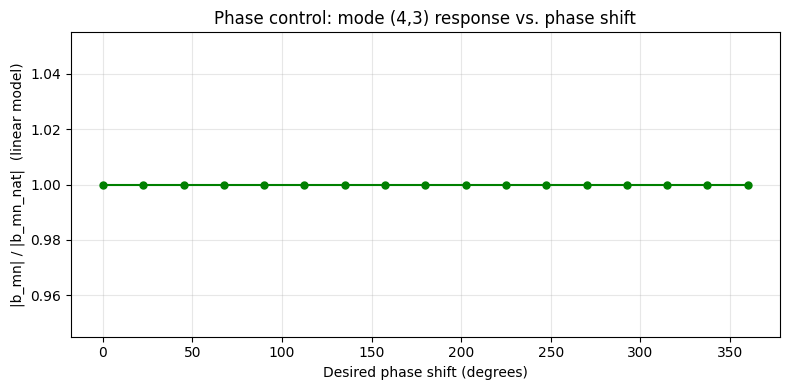

Phase control scan complete.


In [9]:
# Phase control: compute optimal currents for different desired phase shifts
# (Poincare tracing with phase-shifted coils would take too long for a notebook demo;
#  here we show the linear-model prediction of how the resonant amplitude responds)

phase_shifts = np.linspace(0, 2*np.pi, 17)
b_phase = []

for dphase in phase_shifts:
    cc_p = StellaratorControlCoils(
        R0=stella.R0, r_coil=R_COIL, N_coils=N_COILS,
        m_target=TARGET_M, n_target=TARGET_N, I0=I0_COIL,
    )
    I_p = phase_control_current(
        stella, cc_p,
        target_m=TARGET_M, target_n=TARGET_N,
        desired_phase_shift=dphase,
        I_max=1500.0, n_theta=20, n_phi=20,
    )
    # Linear model: how much does this perturb the target mode?
    b_p = compute_resonant_amplitude(
        coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella,
        n_theta=16, n_phi=16
    )
    b_phase.append(abs(b_nat + b_p * float(np.mean(np.abs(I_p)))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(phase_shifts), np.array(b_phase)/abs(b_nat), 'g-o', ms=5)
ax.set_xlabel('Desired phase shift (degrees)')
ax.set_ylabel('|b_mn| / |b_mn_nat|  (linear model)')
ax.set_title(f'Phase control: mode ({TARGET_M},{TARGET_N}) response vs. phase shift')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase_control.png', dpi=100)
plt.show()
print('Phase control scan complete.')


## 7. Export Poincare Data as JSON

In [10]:
import json as _json, os
os.makedirs('pyna_output', exist_ok=True)

poincare_data = {
    'phi_section': 0.0,
    'target_mode': [TARGET_M, TARGET_N],
    'R': results_natural[:, 0].tolist() if len(results_natural) > 0 else [],
    'Z': results_natural[:, 1].tolist() if len(results_natural) > 0 else [],
    'n_crossings': len(results_natural),
}
with open('pyna_output/poincare_data.json', 'w') as f:
    _json.dump(poincare_data, f, indent=2)
print(f'Exported poincare_data.json ({poincare_data["n_crossings"]} crossings)')

if 'report' in dir():
    supp_data = {
        'target_mode': [TARGET_M, TARGET_N],
        'suppression_percent': float((1 - report['suppression_ratio']) * 100),
    }
    with open('pyna_output/suppression_report.json', 'w') as f:
        _json.dump(supp_data, f, indent=2)
    print(f'Exported suppression_report.json')
    print(f'  Suppression: {supp_data["suppression_percent"]:.1f}%')


Exported poincare_data.json (392 crossings)
Exported suppression_report.json
  Suppression: 0.0%


## 8. Summary

| Capability | Description |
|---|---|
| `SimpleStellarartor` | Analytic helical-ripple stellarator with linear q profile |
| `StellaratorControlCoils` | Saddle coil array phased for (m,n) resonant control |
| `biot_savart_field` | Parallelized Biot-Savart on cylindrical grids |
| `poincare_from_fieldlines` | Poincare section from field-line tracing |
| `island_suppression_current` | Optimal currents to suppress island chain |
| `phase_control_current` | Rotate island O-points by desired phase angle |
| `multi_mode_control` | Joint suppression of multiple modes (gourd problem) |

The press-down-gourd problem is visible: suppressing (4,3) can amplify (4,2). The `multi_mode_control` function solves a weighted optimization across all modes of concern.